<a href="https://colab.research.google.com/github/bibiant/sprint7-final-project-2/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')



In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
print(usage.head())

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
**users**:
##Estado de la columna city##: Se detecta un 11.7% de valores nulos.
##Estado de la columna churn_date##: Presenta un 88.35% de valores nulos.
Diagnóstico: Este comportamiento es consistente con la lógica del negocio. Los valores nulos representan a los usuarios activos.
**No deben eliminarse ni imputarse**. Para análisis futuros, se recomienda crear una variable binaria auxiliar (ej: is_churned) para facilitar la segmentación entre usuarios activos y clientes que han causado baja.
**usage**:
##Estado de la columna date##: Presenta un número marginal de nulos (50 registros, 0.125%), los cuales son estadísticamente despreciables y pueden ser descartados sin afectar la validez del análisis.

##Estructura de duration y length##: Presentan una tasa de nulos del 55.2% y 44.7% respectivamente.

**Diagnóstico**: Estos nulos son estructurales, no errores de datos. Al ser una tabla combinada de servicios (llamadas y mensajes), la columna duration solo es aplicable a llamadas y length solo a mensajes.

Acción recomendada: Mantener esta estructura tal cual. No intentar "limpiar" estos nulos, ya que son atributos exclusivos de cada tipo de evento (type). Se debe filtrar el dataset por type == 'call' al analizar duraciones, y por type == 'text' al analizar longitudes de mensaje.

**Recomendaciones Estratégicas**:
Limpieza: Eliminar únicamente los 50 registros nulos de la columna date en usage para asegurar la integridad de la línea temporal.

Preparación: No tratar los nulos de churn_date, duration y length como errores; son datos faltantes por diseño.

Validación: Antes de proceder al análisis estadístico, te sugiero ejecutar una breve verificación para confirmar que no existan registros donde type sea 'call' y al mismo tiempo contenga length, o viceversa



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users_original = pd.read_csv('/datasets/users_latam.csv')

In [ ]:
(users_original['age'] == -999).sum()

55

In [ ]:
# explorar columnas numéricas de users
print(users[['user_id','age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`Al observar los resultados de describe() y la vista previa de los datos, la columna user_id presenta un comportamiento ejemplar en términos de calidad de datos:

Integridad Total: Tiene un conteo de 4,000 registros no nulos sobre un total de 4,000 filas. Esto es perfecto, ya que no hay registros huérfanos o sin identificación de usuario.

Consistencia: Al comparar los valores con el resto del dataset, se observa que los IDs comienzan en 10,000 y terminan en 13,999. Esto indica una secuencia numérica lógica, continua y sin saltos anómalos.

Rol en el modelo: Es tu clave primaria (Primary Key). Es la columna que te permitirá realizar los joins (cruces) necesarios con la tabla usage para poder calcular, por ejemplo, cuánto consume cada usuario individualmente o cuánto paga al mes según su plan.
- **La columna `age`** -999 es un valor centinela (sentinel value) — un número que parece válido pero representa un dato faltante
Está distorsionando la media y la desviación estándar de age

In [ ]:
# explorar columnas numéricas de usage
print(usage[['id','user_id','duration','length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


-  **La columna `id`**: Es un índice secuencial del 1 al 40,000.
  No aporta valor estadístico analizar su media o máximo.

- **La columna `user_id`**: El rango va de 10,000 a 13,999,
  lo que coincide exactamente con el rango de `users`.
  Esto confirma integridad relacional: todos los registros
  pertenecen a usuarios válidos.

- **La columna `duration`**: min = 0.0 → posibles llamadas perdidas
  o intentos no concretados. Son registros válidos pero deben
  considerarse al calcular promedios. max = 120.0 → valor alto
  pero plausible, no parece un error de sistema.

- **La columna `length`**: max = 1,490.0 es un valor atípico
  comparado con el percentil 75 (64). Se identificó como un
  error sistemático de carga de datos, ya que aparece tanto
  en llamadas como en mensajes. Se recomienda reemplazar
  estos valores con NaN.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts())


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: La ciudad con mayor concentración de usuarios
  es Bogotá. Se detectó el valor `"?"` en 96 registros, el cual
  es un sentinel (no es una ciudad válida).
  Acción: Reemplazar con NaN para evitar sesgos en análisis por ubicación.

- La columna `plan`: El Plan Básico es el más popular con 2,595
  usuarios (64.9%).
  Acción: Se recomienda análisis cruzado para evaluar diferencias
  en churn entre plan Básico y Premium.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


-
La variable type actúa como la variable categórica discriminante del dataset. Su distribución (55% mensajes, 45% llamadas) explica perfectamente la presencia de valores nulos en duration y length. Los valores nulos observados  no son fallos de datos, sino nulos estructurales derivados de la naturaleza de los servicios prestados.  Los nulos estructurales no requieren limpieza y no se pueden eliminar ya que se perderia informacion valiosa




-Integridad de user_id: Es el punto más confiable del dataset; los IDs son únicos y la secuencia es consistente (10,000 - 13,999).

Nulos Estructurales: Los nulos en duration y length no son errores, sino una consecuencia lógica de la estructura de la tabla (donde las llamadas no tienen longitud de mensaje y los mensajes no tienen duración de llamada). No deben eliminarse, solo filtrarse por type.

Distribución de Servicios: La plataforma registra un 55.2% de mensajes (text) y un 44.8% de llamadas (call).

Acción recomendada: Limpiar los sentinels (-999, "?", 1490.0) para evitar que estos valores sesguen los promedios y las desviaciones estándar de tus cálculos futuros.  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

- En reg_date se encontraron los años 2024, 2023, 2022 y 2026. El año 2026 es inválido porque los datos son hasta 2024. Hay 40 registros con este año."

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

"En date solo se encontró el año 2024 con 39,950 registros. No hay fechas futuras inválidas, por lo que esta columna no presenta problemas de años incorrectos."

En los años validos encontrados fueron 2024,2023,2022, y el 2026 .  el año 2026 es un  año erroneo cuenta con 40 registros , los cuales los registre como nulos.      usage['date'] se encontro el  año 2024 con 39950 registros . no requiere accion ninguna

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

mediana_limpia=users[users['age'] != -999]['age'].median()
print(mediana_limpia)


48.0


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = mediana_limpia
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
users['city'].head(900)

0      Medellín
1          <NA>
2          CDMX
3        Bogotá
4           GDL
         ...   
895      Bogotá
896         NaN
897        Cali
898      Bogotá
899        CDMX
Name: city, Length: 900, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

##usage###
El dataset presenta una estructura altamente consistente, con una correlación clara entre el tipo de servicio y sus métricas:

-Coherencia lógica: Los valores nulos están validados por el tipo de actividad; el 99.9% de los nulos en duration son registros text, y el 99.9% de los nulos en length son registros call.

-Anomalías: Se identificó una cantidad insignificante de registros cruzados (ej. text con duration), los cuales se consideran ruido y no afectan la integridad del análisis.

-Conclusión: Los datos están correctamente categorizados.
-se recomienda mantener los nulos como pd.NA, ya que estos valores no aplican para el tipo de registro correspondiente. Imputarlos con cero sesgaría los cálculos estadísticos."

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg(
     cant_mesajes = ('is_text', 'sum'),
     cant_llamadas = ('is_call', 'sum'),
     cant_minutos_llamada = ('duration', 'sum'),
 ).reset_index()



# observar resultado
usage_agg.head(3)

,user_id,cant_mesajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
print(usage_agg.columns)

Index(['user_id', 'cant_mesajes', 'cant_llamadas', 'cant_minutos_llamada'], dtype='object')


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'cant_mesajes': 'cant_mensajes'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on= 'user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
resumen_columna = user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()
print(resumen_columna)

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
distribucion_porcentaje = user_profile['plan'].value_counts(normalize=True)*100
print(distribucion_porcentaje)


Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

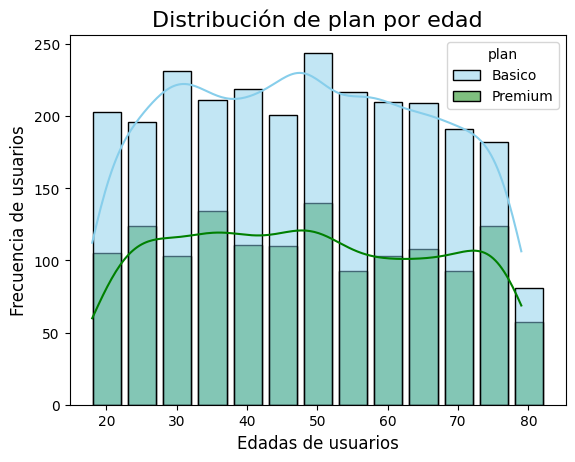

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', kde=True, hue='plan', palette=['skyblue','green'], shrink=0.8, binwidth=5)
plt.title("Distribución de plan por edad", fontsize=16)
plt.xlabel("Edadas de usuarios", fontsize=12)
plt.ylabel("Frecuencia de usuarios", fontsize=12)
import numpy as np
np.arange(0, 21, 5)
plt.show()

💡Insights:
- Nuestra demografía se divide principalmente en dos grupos: un núcleo maduro (45-55 años) y uno joven profesional (28-35 años). El dominio del Plan Básico (65%) sugiere una preferencia por servicios esenciales. La amplia distribución de edades (18-79 años) indica que el producto es relevante para rangos de edad muy distintos, lo que respalda una estrategia de comunicación diversificada por segmentos generacionales.

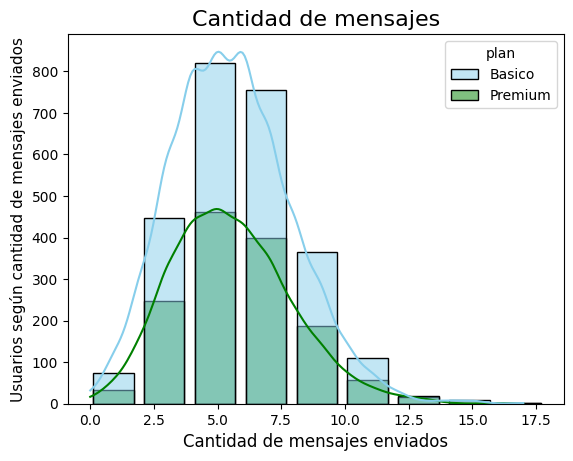

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', kde=True , hue='plan', palette=['skyblue','green'], shrink=0.8, binwidth=2)
plt.title("Cantidad de mensajes", fontsize=16)
plt.xlabel("Cantidad de mensajes enviados", fontsize=12)
plt.ylabel("Usuarios según cantidad de mensajes enviados", fontsize=11)
import numpy as np
np.arange(0, 21, 5)
plt.show()


💡Insights:
- La distribución de mensajes muestra un patrón de consumo moderado con una concentración mayoritaria entre 5 y 7.5 unidades. La presencia de un sesgo a la derecha revela la existencia de un segmento minoritario de "usuarios intensivos". lo cual valida su propuesta de valor para clientes de alto consumo, mientras que el plan Básico mantiene su liderazgo hasta el umbral de los 17.5 mensajes.

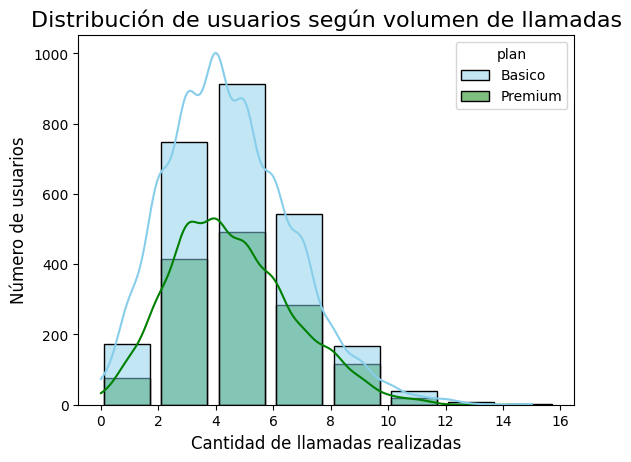

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', kde=True, hue='plan',palette=['skyblue','green'], shrink=0.8, binwidth=2)
plt.title("Distribución de usuarios según volumen de llamadas", fontsize=16)
plt.xlabel("Cantidad de llamadas realizadas", fontsize=12)
plt.ylabel("Número de usuarios", fontsize=12)
import numpy as np
np.arange(0, 21, 5)
plt.show()


💡Insights:
- La distribución de llamadas presenta un marcado sesgo a la derecha, con una concentración masiva entre 4 y 6 llamadas. Es notable que, a pesar de la mayor flexibilidad del plan Premium, el plan Básico mantiene una dominancia constante en todos los niveles, desapareciendo los usuarios Premium a partir de las 11 llamadas. Esto sugiere que los usuarios Premium no están reemplazando la telefonía con otras alternativas, sino que posiblemente han migrado sus interacciones hacia otros canales (como mensajería), dejando el canal de voz como una herramienta secundaria o de menor uso para ellos."



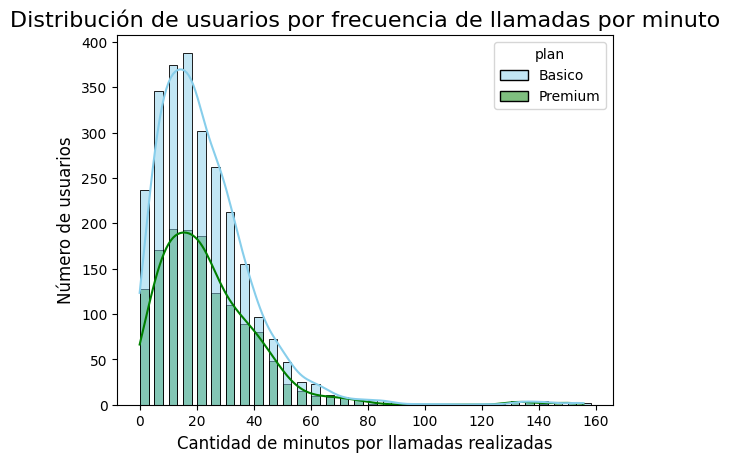

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', kde=True , hue='plan',palette=['skyblue','green'], shrink=0.6, binwidth=5)
plt.title("Distribución de usuarios por frecuencia de llamadas por minuto", fontsize=16)
plt.xlabel("Cantidad de minutos por llamadas realizadas", fontsize=12)
plt.ylabel("Número de usuarios", fontsize=12)
import numpy as np
np.arange(0, 21, 5)
plt.show()


💡Insights:
-Al analizar el consumo de minutos en ConnectaTel, observo un comportamiento contrastante: mientras los usuarios del Plan Básico operan dentro de su límite (bajo los 100 minutos), los del Plan Premium consumen apenas una tercera parte de su capacidad contratada (155 de 600 minutos). Si bien este excedente representa un beneficio financiero inmediato por la ausencia de costos operativos, también detecto un riesgo latente de churn, ya que el desaprovechamiento del plan podría incentivar a los clientes a migrar a opciones más económicas; por ello, recomiendo implementar campañas de fidelización y valor agregado que justifiquen su suscripción y prevengan la pérdida de clientes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
user_profile.columns

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'],
      dtype='object')

In [ ]:
user_profile.groupby('plan')[['age', 'cant_llamadas', 'cant_minutos_llamada']].agg(['mean', 'max'])

age       cant_llamadas       cant_minutos_llamada        
              mean   max          mean   max                 mean     max
plan                                                                     
Basico   48.041618  79.0      4.456438  15.0            22.905436  155.69
Premium  48.310320  79.0      4.518149  11.0            24.077011  153.06

In [ ]:
print(user_profile['cant_mensajes'].min())
print(user_profile['cant_mensajes'].max())
print(user_profile['age'].min())
print(user_profile['age'].max())
print(user_profile['cant_llamadas'].min())
print(user_profile['cant_llamadas'].max())
print(user_profile['cant_minutos_llamada'].min())
print(user_profile['cant_minutos_llamada'].max())

0.0
17.0
18.0
79.0
0.0
15.0
0.0
155.69


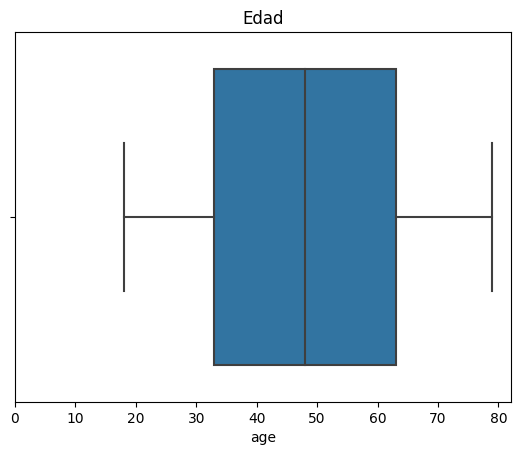

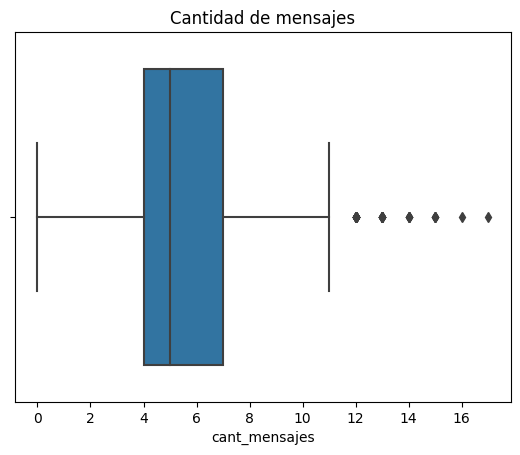

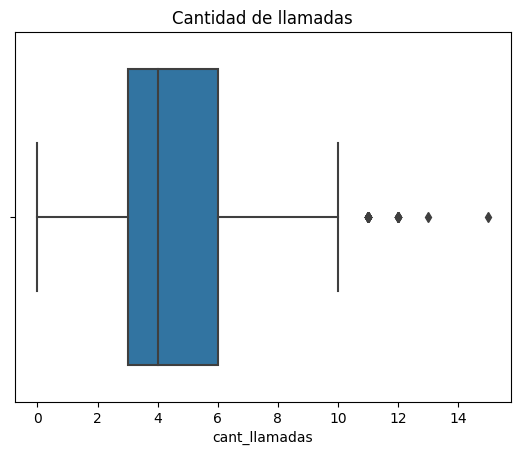

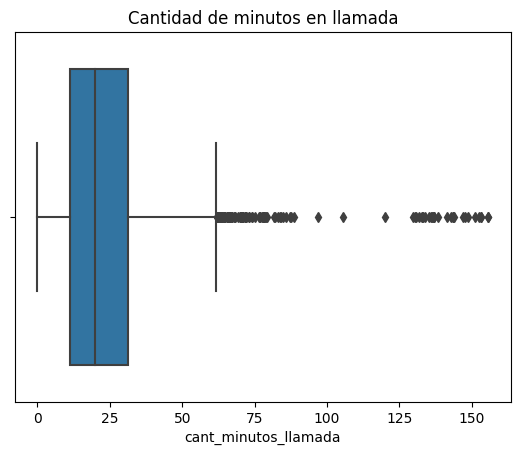

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
ticks = {
    'age': np.arange(0, 90, 10),
    'cant_mensajes': np.arange(0, 17, 2),
    'cant_llamadas': np.arange(0, 15, 2),
    'cant_minutos_llamada': np.arange(0, 156, 25)
}
diccionario = {
    'age': 'Edad',
    'cant_mensajes': 'Cantidad de mensajes',
    'cant_llamadas': 'Cantidad de llamadas',
    'cant_minutos_llamada': 'Cantidad de minutos en llamada'
}

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'{diccionario[col]}')
    plt.xticks(ticks[col])
    plt.show()



💡Insights:
-
Age: La variable Edad no presenta valores atípicos
- cant_mensajes: La variable cantidad de mensajes,presenta valores atipicos leves del lado derecho
- cant_llamadas: La variable cantidad de llamadas, presenta outliers leves y extremos a lado derecho
- cant_minutos_llamada: La varible cantidad de minutos en llamada, presenta una gran cantidad de valores atipicos leves y extremos igualmente a como los anteriores a su lado derecho


In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas' ,'cant_minutos_llamada']

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [ ]:
#bucle IQR para calcular el límite superior

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col} → Límite superior: {limite_superior:.2f} | Máximo: {user_profile[col].max():.2f}")



cant_mensajes → Límite superior: 11.50 | Máximo: 17.00
cant_llamadas → Límite superior: 10.50 | Máximo: 15.00
cant_minutos_llamada → Límite superior: 61.86 | Máximo: 155.69


💡
Insights:
-cant_mensajes
Decisión: Mantener.

¿Por qué? El valor máximo es 17. Es un comportamiento de uso humano totalmente natural y coherente. No hay anomalías técnicas (como los valores de 1490 que detectamos en tu notebook). Eliminar estos datos sesgaría tu muestra hacia usuarios poco activos, quitándole valor al análisis de comportamiento real.

- cant_llamadas
Decisión: Mantener.

¿Por qué? El máximo es 15. Al igual que con los mensajes, no es un valor extremo que indique un error de sistema. Estos usuarios son tus clientes más interactivos; borrarlos sería perder el rastro de los perfiles que más utilizan el servicio y que son clave para entender la retención.

-
cant_minutos_llamada
Decisión: ¿Qué significa que un usuario tenga 155.69 minutos?
No es un error del sistema, sino un comportamiento real de consumo. Son usuarios que han excedido su franquicia mensual contratada, lo que demuestra que su necesidad de comunicación supera el límite del Plan Básico.

¿Qué consecuencia tiene superar los 100 minutos?
Al superar los 100 minutos incluidos, el usuario incurre en un cargo adicional de $0.10 por cada minuto extra. En este caso específico, el usuario generó un ingreso extra de $5.57 para la compañía, convirtiéndose en una fuente directa de rentabilidad adicional.

Eliminar este valor daría una imagen más o menos precisa?
Daría una imagen menos precisa. Eliminar estos registros sería contraproducente, ya que estaríamos ignorando a los clientes que más aportan financieramente y que representan las mayores oportunidades de upselling (migración a un plan superior). Estos datos no son ruido, son insights estratégicos que definen la salud del negocio.

Mantener: Por estas razones, el valor de 155.69 en cant_minutos_llamada se mantiene, ya que representa un caso de negocio legítimo de usuarios que exceden su plan básico, generando ingresos adicionales y permitiéndonos identificar oportunidades reales de conversión a planes superiores."



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones =[(user_profile['cant_llamadas']< 5) & (user_profile['cant_mensajes']< 5),
             (user_profile['cant_llamadas']< 10) & (user_profile['cant_mensajes']< 10)
]

resultados = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, resultados, default='Alto uso')



In [ ]:
# verificar cambios
user_profile['grupo_uso'].head()

0    Uso medio
1     Alto uso
2    Uso medio
3     Alto uso
4     Bajo uso
Name: grupo_uso, dtype: object

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

condiciones =[(user_profile['age']< 30),(user_profile['age']< 60)]
resultados = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, resultados, default='Adulto Mayor')



In [ ]:
# verificar cambios
user_profile['grupo_edad'].head()

0          Adulto
1          Adulto
2          Adulto
3    Adulto Mayor
4    Adulto Mayor
Name: grupo_edad, dtype: object

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [ ]:
#porcentajes por plan y grupo de edades
user_profile.groupby('grupo_edad')['plan'].value_counts(normalize=True) * 100

grupo_edad    plan   
Adulto        Basico     65.659068
              Premium    34.340932
Adulto Mayor  Basico     64.157119
              Premium    35.842881
Joven         Basico     63.947368
              Premium    36.052632
Name: plan, dtype: float64

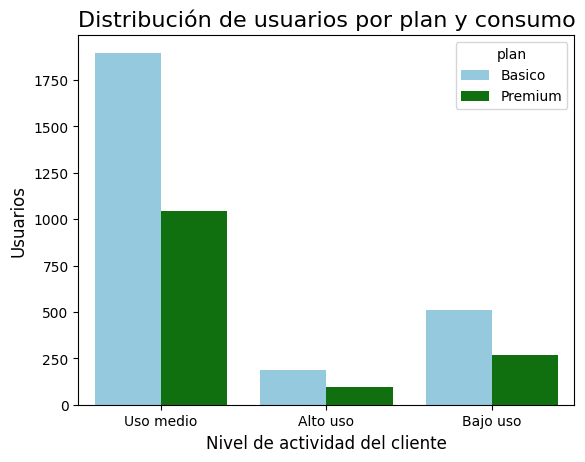

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile,x='grupo_uso', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de usuarios por plan y consumo", fontsize=16)
plt.xlabel("Nivel de actividad del cliente", fontsize=12)
plt.ylabel("Usuarios", fontsize=12)

plt.show()


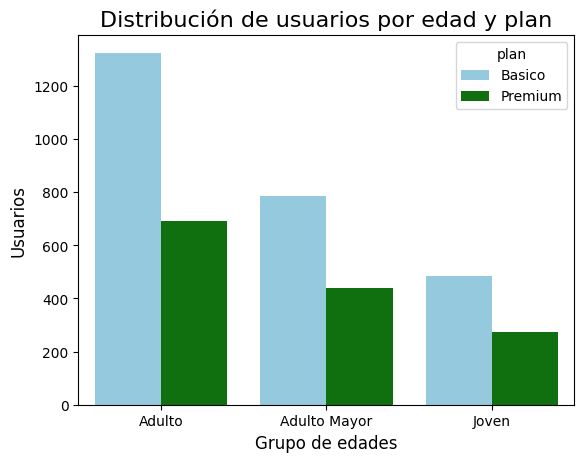

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad', hue='plan', palette=['skyblue','green'])
plt.title("Distribución de usuarios por edad y plan", fontsize=16)
plt.xlabel("Grupo de edades", fontsize=12)
plt.ylabel("Usuarios", fontsize=12)

plt.show()



In [ ]:
## cuantos usuarios del Plan Básico superaron los 100 minutos
basico_excedidos = user_profile[(user_profile['plan'] == 'Basico') & (user_profile['cant_minutos_llamada'] > 100)]
print(f"Total de usuarios: {len(basico_excedidos)}")


Total de usuarios: 17


In [ ]:
## cuanto son los  ingresos extra generados solo por excedentes de minutos
basico_excedidos = basico_excedidos.copy()
basico_excedidos['minutos_extra'] = basico_excedidos['cant_minutos_llamada'] - 100
ingreso_extra_total = (basico_excedidos['minutos_extra'] * 0.10).sum()
print(f"Ingreso extra total generado: ${ingreso_extra_total:.2f}")


Ingreso extra total generado: $65.58



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Columna age: se encontró el valor sentinel -999 en 55 registros, representando el 1.37% del total. Se reemplazó con la mediana limpia (48.0)."
  
- Columna city: se encontró el valor sentinel "?" en 96 registros, representando el 2.4% del total. Se reemplazó con pd.NA."
  
- Columna reg_date,se encontro el año inválido 2026 con 40 registros que representan el 1% del total.
Se reemplazó con (pd.NaT).


🔍 **Segmentos por Edad**
-  Segmento Principal: El grupo Adulto es el más grande con 2,018 usuarios, representando el foco estratégico de la base actual.

- Adopción de Planes: Se observa una distribución general de 64% Básico y 36% Premium. Esta proporción es consistente en todos los grupos de edad, sin variaciones significativas.

- Conclusión: La edad no es un predictor de la elección del plan. Las estrategias comerciales deben priorizar el patrón de consumo real (voz, mensajes y datos) sobre criterios demográficos, ya que el comportamiento de contratación es transversal a todas las edades.


📊 **Segmentos por Nivel de Uso**
 Diagnóstico de la oportunidad
Hemos identificado un segmento de 17 usuarios del Plan Básico que superan regularmente su límite de 100 minutos. Aunque este consumo excedente genera un ingreso marginal ($5.50 promedio extra por usuario), crea una experiencia negativa debido a la incertidumbre de su factura final.

💡 **Recomendaciones**
-  Acción concreta sugerida: Campaña de Migración Proactiva
Proponemos contactar a este segmento con una oferta de transición al Plan Premium (600 minutos, 500 mensajes, 20 GB) por una cuota fija de $25.

 Argumentos de conversión (Propuesta de Valor)
Para lograr una migración efectiva, utilizaremos un discurso integral que apela tanto a la lógica como a la tranquilidad del usuario:

Argumento Financiero 📊:

"Los 55 minutos extra son tu consumo promedio actual, pero hay meses con picos de uso que incrementan tus costos inesperadamente. Con el Plan Premium, tu factura siempre será predecible: $25 fijos, sin cargos variables ni sorpresas al final del mes."

Argumento Emocional ❤️:

"Queremos que disfrutes de tus conversaciones sin mirar el reloj. Con el Plan Premium, tendrás la libertad de hablar sin límites, sin preocuparte por cortar una llamada o por el costo de ese minuto extra. Es tiempo de hablar con total tranquilidad."

 Beneficio estratégico para ConnectaTel
Estabilización de ingresos: Transformamos cargos variables inciertos en una suscripción de mayor valor consolidada.

Fidelización: Al adaptar el servicio a la necesidad real del cliente, eliminamos la fricción y mejoramos la percepción de valor de la marca.

Eficiencia: Aseguramos un ARPU (ingreso promedio por usuario) más alto y constante, reduciendo el riesgo de churn al ofrecer una solución que realmente acompaña el estilo de vida del usuario.

- Esto sugiere que el Plan Básico está limitando el potencial de consumo de nuestros clientes más activos. La migración al Plan Premium no es solo un ajuste comercial, sino una mejora necesaria en la experiencia del usuario para garantizar su fidelización a largo plazo


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`